In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels as sm
import seaborn as sns
import sklearn as sk
import warnings
warnings.filterwarnings('ignore')

## EDA Continued

In [ ]:
url = 'https://raw.githubusercontent.com/aspenwang-vassar/CMPU-250-Project-Group-1/refs/heads/main/data/cleaned_data.csv'
df = pd.read_csv(url)
df_copy = df.copy()
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Hospital,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results,Race,Admission Length,Age Group
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Sons and Miller,Blue Cross,18856.281306,Urgent,2024-02-02,Paracetamol,Normal,White,2,21-40
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Kim Inc,Medicare,33643.327287,Emergency,2019-08-26,Ibuprofen,Inconclusive,Hispanic,6,40-65
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Cook PLC,Aetna,27955.096079,Emergency,2022-10-07,Aspirin,Normal,White,15,65+
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,"Hernandez Rogers and Vang,",Medicare,37909.782410,Elective,2020-12-18,Ibuprofen,Abnormal,White,30,21-40
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,White-White,Aetna,14238.317814,Urgent,2022-10-09,Penicillin,Abnormal,White,20,40-65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,Elizabeth Jackson,42,Female,O+,Asthma,2020-08-16,Jones-Thompson,Blue Cross,2650.714952,Elective,2020-09-15,Penicillin,Abnormal,African American,30,40-65
55496,Kyle Perez,61,Female,AB-,Obesity,2020-01-23,Tucker-Moyer,Cigna,31457.797307,Elective,2020-02-01,Aspirin,Normal,White,9,40-65
55497,Heather Wang,38,Female,B+,Hypertension,2020-07-13,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,Urgent,2020-08-10,Ibuprofen,Abnormal,Hispanic,28,21-40
55498,Jennifer Jones,43,Male,O-,Arthritis,2019-05-25,"Jackson Todd and Castro,",Medicare,32451.092358,Elective,2019-05-31,Ibuprofen,Abnormal,Hispanic,6,40-65


## Modifying our Data

In [ ]:
#Reducing Billing Amount Category by a factor of 10(10%)

df['Billing Amount'] = df['Billing Amount'] /10


In [ ]:
#Increase billing amount by $3,025 to account for the daily cost of a hostpital stay
df['Billing Amount'] = df['Billing Amount'] + (3025 * df['Admission Length'])

In [ ]:
# Adjust the Billing Amount based on the daily costs of each

#Create the dictionary of daily costs
daily_costs = {
    'Diabetes': 54.00,
    'Asthma': 9.00,
    'Hypertension': 7.56,
    'Obesity': 6.87,
    'Arthritis': 14.00,
    'Cancer': 3400.00
}
# get the daily cost of each treatment
cost = df['Medical Condition'].map(daily_costs).fillna(0)

#Calculate adjsutment amount and add it to the billing amount
df['Billing Amount'] = df['Billing Amount'] + (cost * df['Admission Length'])

print(df[['Medical Condition', 'Admission Length', 'Billing Amount']].head())

  Medical Condition  Admission Length  Billing Amount
0            Cancer                 2    14735.628131
1           Obesity                 6    21555.552729
2           Obesity                15    48273.559608
3          Diabetes                30    96160.978241
4            Cancer                20   129923.831781


In [ ]:
#Increment billing amount based on age
conditions = [
    df['Age'] < 21,
    (df['Age'] >= 21) & (df['Age'] <= 40),
    (df['Age'] > 40) & (df['Age'] <= 65),
    df['Age'] > 65
]
choices = [2000, 3000, 6500, 11000]
df['Billing Amount'] = df['Billing Amount'] + np.select(conditions, choices, default=0)
df

df['Billing Amount']

,Billing Amount
0,17735.628131
1,28055.552729
2,59273.559608
3,99160.978241
4,136423.831781
...,...
55495,97785.071495
55496,36932.609731
55497,90673.756472
55498,27979.109236


In [ ]:
#Adding 2K for Admission types of Emergency
df.loc[df['Admission Type'] == 'Emergency', 'Billing Amount'] += 2000


df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Hospital,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results,Race,Admission Length,Age Group
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Sons and Miller,Blue Cross,17735.628131,Urgent,2024-02-02,Paracetamol,Normal,White,2,21-40
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Kim Inc,Medicare,30055.552729,Emergency,2019-08-26,Ibuprofen,Inconclusive,Hispanic,6,40-65
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Cook PLC,Aetna,61273.559608,Emergency,2022-10-07,Aspirin,Normal,White,15,65+
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,"Hernandez Rogers and Vang,",Medicare,99160.978241,Elective,2020-12-18,Ibuprofen,Abnormal,White,30,21-40
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,White-White,Aetna,136423.831781,Urgent,2022-10-09,Penicillin,Abnormal,White,20,40-65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,Elizabeth Jackson,42,Female,O+,Asthma,2020-08-16,Jones-Thompson,Blue Cross,97785.071495,Elective,2020-09-15,Penicillin,Abnormal,African American,30,40-65
55496,Kyle Perez,61,Female,AB-,Obesity,2020-01-23,Tucker-Moyer,Cigna,36932.609731,Elective,2020-02-01,Aspirin,Normal,White,9,40-65
55497,Heather Wang,38,Female,B+,Hypertension,2020-07-13,"and Mahoney Johnson Vasquez,",UnitedHealthcare,90673.756472,Urgent,2020-08-10,Ibuprofen,Abnormal,Hispanic,28,21-40
55498,Jennifer Jones,43,Male,O-,Arthritis,2019-05-25,"Jackson Todd and Castro,",Medicare,27979.109236,Elective,2019-05-31,Ibuprofen,Abnormal,Hispanic,6,40-65


In [ ]:
#Multipliers for different Race's average billing amount
df.loc[df['Race'] == 'Hispanic', 'Billing Amount'] *= 1.28
df.loc[df['Race'] == 'African American', 'Billing Amount'] *= 1.57
df.loc[df['Race'] == 'White', 'Billing Amount'] *= 1.74
df.loc[df['Race'] == 'Multiracial', 'Billing Amount'] *= 1.98

print(df[['Race', 'Billing Amount']].head())
df

       Race  Billing Amount
0     White    30859.992947
1  Hispanic    38471.107493
2     White   106615.993718
3     White   172540.102139
4     White   237377.467300


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Hospital,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results,Race,Admission Length,Age Group
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Sons and Miller,Blue Cross,30859.992947,Urgent,2024-02-02,Paracetamol,Normal,White,2,21-40
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Kim Inc,Medicare,38471.107493,Emergency,2019-08-26,Ibuprofen,Inconclusive,Hispanic,6,40-65
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Cook PLC,Aetna,106615.993718,Emergency,2022-10-07,Aspirin,Normal,White,15,65+
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,"Hernandez Rogers and Vang,",Medicare,172540.102139,Elective,2020-12-18,Ibuprofen,Abnormal,White,30,21-40
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,White-White,Aetna,237377.467300,Urgent,2022-10-09,Penicillin,Abnormal,White,20,40-65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,Elizabeth Jackson,42,Female,O+,Asthma,2020-08-16,Jones-Thompson,Blue Cross,153522.562248,Elective,2020-09-15,Penicillin,Abnormal,African American,30,40-65
55496,Kyle Perez,61,Female,AB-,Obesity,2020-01-23,Tucker-Moyer,Cigna,64262.740931,Elective,2020-02-01,Aspirin,Normal,White,9,40-65
55497,Heather Wang,38,Female,B+,Hypertension,2020-07-13,"and Mahoney Johnson Vasquez,",UnitedHealthcare,116062.408284,Urgent,2020-08-10,Ibuprofen,Abnormal,Hispanic,28,21-40
55498,Jennifer Jones,43,Male,O-,Arthritis,2019-05-25,"Jackson Todd and Castro,",Medicare,35813.259822,Elective,2019-05-31,Ibuprofen,Abnormal,Hispanic,6,40-65


In [ ]:
from google.colab import files

df.to_csv('full_data.csv', index=False)
files.download('full_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

https://github.com/aspenwang-vassar/CMPU-250-Project-Group-1/blob/main/data/clean_data.csv## Datasets

In [ ]:
# compare the prediciton performance across different biased/unbibaased datasets using different models.

# Modeling

## Race/Ethinicity Split

### Create Biased Datasets

In [ ]:


def create_biased_dataset(df, target_percentage_white):
    """
    Creates a biased dataset by randomly changing 'Minority' rows to
    'White' to achieve the target percentage.
    """
    # Create a copy
    biased_df = df.copy()

    total_rows = len(biased_df)
    target_white_count = int(total_rows * target_percentage_white)

    white_indices = biased_df[biased_df['Race'] == 'White'].index
    current_white_count = len(white_indices)

    rows_to_change = target_white_count - current_white_count

    if rows_to_change < 0:
        print(f"Warning: The data already has more than {target_percentage_white:.0%} "
              f"White rows. No changes made.")
        return biased_df

    minority_indices = biased_df[biased_df['Race'] != 'White'].index

    if len(minority_indices) < rows_to_change:
        raise ValueError(f"Not enough minority rows to flip. "
                         f"Need to change {rows_to_change}, but only "
                         f"{len(minority_indices)} are available.")

    # Randomly select Minority rows to flip to White
    indices_to_flip = np.random.choice(minority_indices,
                                       size=rows_to_change,
                                       replace=False)

    # Apply the change
    biased_df.loc[indices_to_flip, 'Race'] = 'White'

    return biased_df


# Create a dataset that is 70% White
df_70 = create_biased_dataset(df, 0.70)

# Create a dataset that is 80% White
df_80 = create_biased_dataset(df, 0.80)

# Create a dataset that is 90% White
df_90 = create_biased_dataset(df, 0.90)


print("\n--- 70% White (Modified) Dataset ---")
print(f"Total rows: {len(df_70)}")
print(df_70['Race'].value_counts(normalize=True))

print("\n--- 80% White (Modified) Dataset ---")
print(f"Total rows: {len(df_80)}")
print(df_80['Race'].value_counts(normalize=True))

print("\n--- 90% White (Modified) Dataset ---")
print(f"Total rows: {len(df_90)}")
print(df_90['Race'].value_counts(normalize=True))


--- 70% White (Modified) Dataset ---
Total rows: 55500
Race
White               0.700000
Hispanic            0.139387
African American    0.094703
Asian               0.044901
Multiracial         0.021009
Name: proportion, dtype: float64

--- 80% White (Modified) Dataset ---
Total rows: 55500
Race
White               0.800000
Hispanic            0.092901
African American    0.062901
Asian               0.029459
Multiracial         0.014739
Name: proportion, dtype: float64

--- 90% White (Modified) Dataset ---
Total rows: 55500
Race
White               0.900000
Hispanic            0.046306
African American    0.032108
Asian               0.014270
Multiracial         0.007315
Name: proportion, dtype: float64


### Train-Test Split for Racial Biased Dataset

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score


races = ['White', 'Hispanic', 'Black', 'Asian', 'Multiracial']

original_df = df.copy()

df_unbiased = original_df

# Create our 4 TRAINING sets and 2 TEST sets

# Unbiased data
train_unbiased, test_unbiased = train_test_split(df_unbiased, test_size=0.2, random_state=42)

# 70% Biased data
train_70, _ = train_test_split(df_70, test_size=0.2, random_state=42)

# 80% Biased data
train_80, _ = train_test_split(df_80, test_size=0.2, random_state=42)

# 90% Biased data
train_90, test_biased_90 = train_test_split(df_90, test_size=0.2, random_state=42)

# Our 4 training sets
training_sets = {
    "unbiased": train_unbiased,
    "biased_70": train_70,
    "biased_80": train_80,
    "biased_90": train_90
}

# Our 2 test sets
test_sets = {
    "test_unbiased": test_unbiased,
    "test_biased_90": test_biased_90
}

### Feature Selections and Pipelines

In [ ]:
# Feature Selection
features = [
    'Age',
    'Admission Length',
    'Race',
    'Gender',
    'Blood Type',
    'Medical Condition',
    'Insurance Provider',
    'Admission Type',
    'Medication',
    'Test Results',
    'Age Group']
target = 'Billing Amount'

# Create the preprocessing pipeline
numeric_features = ['Age', 'Admission Length']
categorical_features = [
    'Race',
    'Gender',
    'Blood Type',
    'Medical Condition',
    'Insurance Provider',
    'Admission Type',
    'Medication',
    'Test Results',
    'Age Group'
    ]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Define 3 models
models = {
    "LinearRegression": Pipeline(steps=[('preprocessor', preprocessor),
                                       ('regressor', LinearRegression())]),

    "PolynomialRegression_D2": Pipeline(steps=[('preprocessor', preprocessor),
                                               ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
                                               ('regressor', LinearRegression())]),

    "KNN_Regression_k15": Pipeline(steps=[('preprocessor', preprocessor),
                                         ('regressor', KNeighborsRegressor(n_neighbors=15))])
}


### Model training

In [ ]:

# Store fitted models and results
fitted_models = {}
aggregate_results = []

print("Training Models")

for train_name, train_df in training_sets.items():
    X_train = train_df[features]
    y_train = train_df[target]

    for model_name, model in models.items():
        print(f"Fitting {model_name} on {train_name} data")

        # Fit the model
        model.fit(X_train, y_train)

        # Store the fitted model
        fitted_models[(train_name, model_name)] = model

print("\n Aggregating Performance Results")

# Evaluate models on
for (train_name, model_name), model in fitted_models.items():
    for test_name, test_df in test_sets.items():

        X_test = test_df[features]    #type:ignore
        y_test = test_df[target]      #type:ignore

        y_pred = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        aggregate_results.append({
            "Train_Set": train_name,
            "Model": model_name,
            "Test_Set": test_name,
            "Mean Prediction": np.mean(y_pred),
            "RMSE": rmse,
            "R2": r2
        })

# Display aggregate results in a clean DF
results_df = pd.DataFrame(aggregate_results)
print(results_df.to_string())


Training Models
Fitting LinearRegression on unbiased data
Fitting PolynomialRegression_D2 on unbiased data
Fitting KNN_Regression_k15 on unbiased data
Fitting LinearRegression on biased_70 data
Fitting PolynomialRegression_D2 on biased_70 data
Fitting KNN_Regression_k15 on biased_70 data
Fitting LinearRegression on biased_80 data
Fitting PolynomialRegression_D2 on biased_80 data
Fitting KNN_Regression_k15 on biased_80 data
Fitting LinearRegression on biased_90 data
Fitting PolynomialRegression_D2 on biased_90 data
Fitting KNN_Regression_k15 on biased_90 data

 Aggregating Performance Results
    Train_Set                    Model        Test_Set  Mean Prediction          RMSE        R2
0    unbiased         LinearRegression   test_unbiased     99528.762127  20516.918143  0.895113
1    unbiased         LinearRegression  test_biased_90    104379.007899  24194.817257  0.854138
2    unbiased  PolynomialRegression_D2   test_unbiased     99307.240808   8057.324823  0.983824
3    unbiased  Po

Display Results

In [ ]:
results_df.sort_values(by='RMSE')

,Train_Set,Model,Test_Set,Mean Prediction,RMSE,R2
2,unbiased,PolynomialRegression_D2,test_unbiased,99307.240808,8057.324823,0.983824
8,biased_70,PolynomialRegression_D2,test_unbiased,99307.240808,8057.324823,0.983824
14,biased_80,PolynomialRegression_D2,test_unbiased,99307.240808,8057.324823,0.983824
20,biased_90,PolynomialRegression_D2,test_unbiased,99307.240808,8057.324823,0.983824
9,biased_70,PolynomialRegression_D2,test_biased_90,104200.638460,16525.440008,0.931954
15,biased_80,PolynomialRegression_D2,test_biased_90,104200.638460,16525.440008,0.931954
21,biased_90,PolynomialRegression_D2,test_biased_90,104200.638460,16525.440008,0.931954
3,unbiased,PolynomialRegression_D2,test_biased_90,104200.638460,16525.440008,0.931954
12,biased_80,LinearRegression,test_unbiased,99528.762127,20516.918143,0.895113
18,biased_90,LinearRegression,test_unbiased,99528.762127,20516.918143,0.895113


Group Performance Analysis

In [ ]:
# To analyze model-specific bias, we compute the RMSE for White and Minority groups.
# We then measure the disparity in RMSE between the two groups.
# Finally, we compare how this gap changes across each model (Linear, KNN, etc.)
# to see which models amplify or reduce the bias from the training data.

model_names = list(models.keys())
train_names = list(training_sets.keys())

# --- 2. Prepare the Test Data ---
X_test_unbiased = test_unbiased[features]   #type:ignore
y_test_unbiased = test_unbiased[target]     #type:ignore

# create a new df for analysis
test_data_for_analysis = test_unbiased.copy()

# Create the Group column
test_data_for_analysis['Group'] = test_data_for_analysis['Race']    #type:ignore


# --- 3. Run the Full Analysis Loop ---
full_bias_analysis_results = []

for model_name in model_names:

    for train_name in train_names:

        #get fitted models
        model = fitted_models[(train_name, model_name)]

        # Make predictions on the unbiased test set and save it
        predictions = model.predict(X_test_unbiased)
        pred_col_name = f'pred_{train_name}_{model_name}'
        test_data_for_analysis[pred_col_name] = predictions    #type:ignore

        # Calculate RMSE for each group
        for group in ["White", 'African American', 'Hispanic', 'Asian', 'Multiracial']:

            group_data = test_data_for_analysis[test_data_for_analysis['Group'] == group]      #type:ignore

            if len(group_data) > 0:
                group_rmse = np.sqrt(mean_squared_error(
                    group_data[target],
                    group_data[pred_col_name]
                ))

                full_bias_analysis_results.append({
                    "Model": model_name,
                    "Train_Set": train_name,
                    "Group": group,
                    "Group_RMSE": group_rmse
                })

# Create new DF
group_bias_df = pd.DataFrame(full_bias_analysis_results)

print("---- Bias Data: ---- ")
print(group_bias_df.to_string(index=False))


---- Bias Data: ---- 
                  Model Train_Set            Group   Group_RMSE
       LinearRegression  unbiased            White 21319.928060
       LinearRegression  unbiased African American 16179.287163
       LinearRegression  unbiased         Hispanic 18243.581819
       LinearRegression  unbiased            Asian 24550.952401
       LinearRegression  unbiased      Multiracial 25873.378820
       LinearRegression biased_70            White 21319.928060
       LinearRegression biased_70 African American 16179.287163
       LinearRegression biased_70         Hispanic 18243.581819
       LinearRegression biased_70            Asian 24550.952401
       LinearRegression biased_70      Multiracial 25873.378820
       LinearRegression biased_80            White 21319.928060
       LinearRegression biased_80 African American 16179.287163
       LinearRegression biased_80         Hispanic 18243.581819
       LinearRegression biased_80            Asian 24550.952401
       LinearRegre

Plot 3 Group Specific RMSE on the unbiased test set for different racial group.

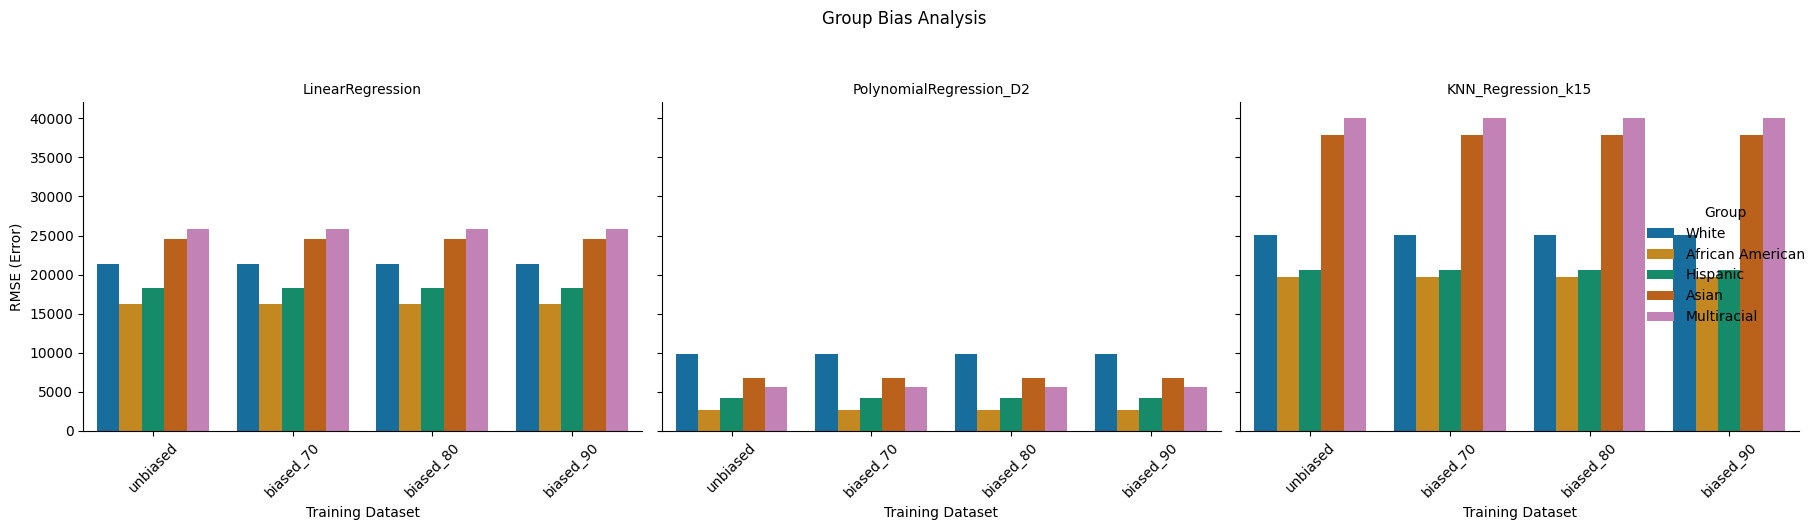

Group-specific RMSE on the unbiased test set for models trained on datasets with varying racial bias. Note that for each model (e.g., PolynomialRegression_D2), the error for each group (e.g., 'White') is identical across all four trained models, from 'unbiased' to 'biased_90'.


In [ ]:
# Create a colorblind-friendly palette with 6 colors and convert to hex
colorblind_palette = sns.color_palette("colorblind", 5).as_hex()

# Plot the results
g = sns.catplot(
    data=group_bias_df,
    x='Train_Set',
    y='Group_RMSE',
    hue='Group',
    col='Model',
    kind='bar',
    height=5,
    aspect=1.1,
    order=['unbiased', 'biased_70', 'biased_80', 'biased_90'],
    palette=colorblind_palette
)

g.fig.suptitle('Group Bias Analysis', y=1.05)
g.set_axis_labels('Training Dataset', 'RMSE (Error)')
g.set_titles('{col_name}')
g.set_xticklabels(rotation=45)
plt.tight_layout()
plt.show()
alt_text = """Group-specific RMSE on the unbiased test set for models trained on datasets with varying racial bias. Note that for each model (e.g., PolynomialRegression_D2), the error for each group (e.g., 'White') is identical across all four trained models, from 'unbiased' to 'biased_90'."""
print(alt_text)

# Age-Group Bias

In [ ]:
url = 'https://raw.githubusercontent.com/aspenwang-vassar/CMPU-250-Project-Group-1/refs/heads/main/data/full_data.csv'
data = pd.read_csv(url)
#data = pd.read_csv('Data_clean_unbiased.csv')
#Make a copy of data
copy_data = data.copy()

data.head()



,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Hospital,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results,Race,Admission Length,Age Group
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Sons and Miller,Blue Cross,30859.992947,Urgent,2024-02-02,Paracetamol,Normal,White,2,21-40
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Kim Inc,Medicare,38471.107493,Emergency,2019-08-26,Ibuprofen,Inconclusive,Hispanic,6,40-65
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Cook PLC,Aetna,106615.993718,Emergency,2022-10-07,Aspirin,Normal,White,15,65+
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,"Hernandez Rogers and Vang,",Medicare,172540.102139,Elective,2020-12-18,Ibuprofen,Abnormal,White,30,21-40
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,White-White,Aetna,237377.467300,Urgent,2022-10-09,Penicillin,Abnormal,White,20,40-65


# Adding Dummy Variables for Categorical Features

In [ ]:
#Columns that need to Dummy Variables:
col_dummy = ['Gender','Blood Type','Medical Condition','Insurance Provider','Admission Type','Medication','Test Results','Race','Age Group']

#Columns that we want but don't need to be converted
cols_continuous = [column for column in data.columns if column not in col_dummy]

#Remove features we are NOT regressing on
cols_remove = ['Date of Admission','Discharge Date','Hospital']
cols_continuous = [col for col in cols_continuous if col not in cols_remove]

#Add Age Group variable(needed for creating bias dataset)
cols_continuous.append('Age Group')
print(cols_continuous)


['Name', 'Age', 'Billing Amount', 'Admission Length', 'Age Group']


In [ ]:
#DataFrame to convert dummy variables into categorical features
new_data = data[col_dummy]
new_data = new_data.astype('category')  #Converts each dummy variable first into categorical variables
print(new_data.dtypes)
new_data = pd.get_dummies(new_data,columns = col_dummy).astype(int).astype('category') #Now add the corresponding dummy variables for each categorical variable
print(new_data.dtypes[1:10])
display(new_data.head())

#Concatenate to create full Data
concat_data = data[cols_continuous]
data = pd.concat([concat_data,new_data],axis = 1)
display(data.head())


Gender                category
Blood Type            category
Medical Condition     category
Insurance Provider    category
Admission Type        category
Medication            category
Test Results          category
Race                  category
Age Group             category
dtype: object
Gender_Male       category
Blood Type_A+     category
Blood Type_A-     category
Blood Type_AB+    category
Blood Type_AB-    category
Blood Type_B+     category
Blood Type_B-     category
Blood Type_O+     category
Blood Type_O-     category
dtype: object


,Gender_Female,Gender_Male,Blood Type_A+,Blood Type_A-,Blood Type_AB+,Blood Type_AB-,Blood Type_B+,Blood Type_B-,Blood Type_O+,Blood Type_O-,...,Test Results_Normal,Race_African American,Race_Asian,Race_Hispanic,Race_Multiracial,Race_White,Age Group_0-21,Age Group_21-40,Age Group_40-65,Age Group_65+
0,0,1,0,0,0,0,0,1,0,0,...,1,0,0,0,0,1,0,1,0,0
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
2,1,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1
3,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
4,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0


,Name,Age,Billing Amount,Admission Length,Age Group,Gender_Female,Gender_Male,Blood Type_A+,Blood Type_A-,Blood Type_AB+,...,Test Results_Normal,Race_African American,Race_Asian,Race_Hispanic,Race_Multiracial,Race_White,Age Group_0-21,Age Group_21-40,Age Group_40-65,Age Group_65+
0,Bobby Jackson,30,30859.992947,2,21-40,0,1,0,0,0,...,1,0,0,0,0,1,0,1,0,0
1,Leslie Terry,62,38471.107493,6,40-65,0,1,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,Danny Smith,76,106615.993718,15,65+,1,0,0,1,0,...,1,0,0,0,0,1,0,0,0,1
3,Andrew Watts,28,172540.102139,30,21-40,1,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
4,Adrienne Bell,43,237377.467300,20,40-65,1,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0


# Creating Age-Grouped Biased Datasets

In [ ]:
#We want to skew the number of patients between 0-40 to be greater than the number of patients between 40-65+
prop = [0.3,0.2,0.1]  #The proportions we are controlling for(70-30,80-20,and 90-10)

#The Age Group we want to be the majority in our Data
group_majority = data[(data['Age Group'] == '0-21') | (data['Age Group'] == '21-40')]

#The Age Group we want to be the minority in our Data
group_minority = data[(data['Age Group'] == '40-65') | (data['Age Group'] == '65+')]
age_bias_datasets = []

#Creating the biased data
for proportion in prop:
    n = 0
    len_data = 10000  #We will shrink our data down into 1000 observations per dataset
    row_major = 0
    row_minor = 0
    index_major = []
    index_minor = []
    np.random.seed(42)

    while n < len_data:
        randy = np.random.rand()
        if(randy > proportion): #Ensures majority of our patients are from 0-40 age group
            index_major.append(row_major)
            row_major += 1
        else:
            index_minor.append(row_minor)
            row_minor += 1
        n += 1

    age_bias_datasets.append(pd.concat([group_majority.iloc[index_major,:],group_minority.iloc[index_minor,:]]))

age_bias7030,age_bias8020,age_bias9010 = age_bias_datasets[:3]

#Checking Proportions
for dataset in age_bias_datasets:
    counts = dataset['Age Group'].value_counts()
    num_obs = len(dataset['Age Group'])
    print(counts)
    print('Number of Observations',num_obs)

    #Checking for each group
    print('For Majority(70,80,90) Group', (counts['21-40'] + counts['0-21']) / num_obs)
    print('For Minority(30,20,10) Group', (counts['40-65'] + counts['65+']) / num_obs,'\n')


Age Group
21-40    5719
40-65    1662
65+      1391
0-21     1228
Name: count, dtype: int64
Number of Observations 10000
For Majority(70,80,90) Group 0.6947
For Minority(30,20,10) Group 0.3053 

Age Group
21-40    6560
0-21     1397
40-65    1104
65+       939
Name: count, dtype: int64
Number of Observations 10000
For Majority(70,80,90) Group 0.7957
For Minority(30,20,10) Group 0.2043 

Age Group
21-40    7405
0-21     1564
40-65     584
65+       447
Name: count, dtype: int64
Number of Observations 10000
For Majority(70,80,90) Group 0.8969
For Minority(30,20,10) Group 0.1031 



## Training Models using Linear,Polynomial,and KNN Regression

# Creating Train and test splits for each dataset

In [ ]:
#1.Create train and test splits for each dataset

#Features:
feature_names = list(data.columns)
remove_vars = ['Name','Age Group','Billing Amount']  #Billing Amount is our Outcome, see all features below
feature_names = [var for var in feature_names if var not in remove_vars]
print('Features: ',feature_names)
#Outcome is Billing Amount

#Full Data
features0 = data[feature_names]
outcome0 = data['Billing Amount']
X_train,X_test,y_train,y_test = sk.model_selection.train_test_split(features0,outcome0,test_size = 0.2)

#70-30 Train,Test
features = age_bias7030[feature_names]
outcome = age_bias7030['Billing Amount']
X_train7030,X_test7030,y_train7030,y_test7030 = sk.model_selection.train_test_split(features,outcome,test_size = 0.2)

#80-20 Train,Test
features1 = age_bias8020[feature_names]
outcome1 = age_bias8020['Billing Amount']
X_train8020,X_test8020,y_train8020,y_test8020 = sk.model_selection.train_test_split(features1,outcome1,test_size = 0.2)

#90-10 Train,Test
features2 = age_bias9010[feature_names]
outcome2 = age_bias9010['Billing Amount']
X_train9010,X_test9010,y_train9010,y_test9010 = sk.model_selection.train_test_split(features2,outcome2,test_size = 0.3)


Features:  ['Age', 'Admission Length', 'Gender_Female', 'Gender_Male', 'Blood Type_A+', 'Blood Type_A-', 'Blood Type_AB+', 'Blood Type_AB-', 'Blood Type_B+', 'Blood Type_B-', 'Blood Type_O+', 'Blood Type_O-', 'Medical Condition_Arthritis', 'Medical Condition_Asthma', 'Medical Condition_Cancer', 'Medical Condition_Diabetes', 'Medical Condition_Hypertension', 'Medical Condition_Obesity', 'Insurance Provider_Aetna', 'Insurance Provider_Blue Cross', 'Insurance Provider_Cigna', 'Insurance Provider_Medicare', 'Insurance Provider_UnitedHealthcare', 'Admission Type_Elective', 'Admission Type_Emergency', 'Admission Type_Urgent', 'Medication_Aspirin', 'Medication_Ibuprofen', 'Medication_Lipitor', 'Medication_Paracetamol', 'Medication_Penicillin', 'Test Results_Abnormal', 'Test Results_Inconclusive', 'Test Results_Normal', 'Race_African American', 'Race_Asian', 'Race_Hispanic', 'Race_Multiracial', 'Race_White', 'Age Group_0-21', 'Age Group_21-40', 'Age Group_40-65', 'Age Group_65+']


# Linear Regression

In [ ]:
#Linear Regression:
algo_linear = sk.linear_model.LinearRegression()

#For Full Dataset
model_lin = algo_linear.fit(X_train,y_train)
print('Full Coefficients:',model_lin.coef_)
print('Full Intercepts:',model_lin.intercept_,'\n')

#For 70-30
model_linear7030 = algo_linear.fit(X_train7030,y_train7030)
print('70%-30% Coefficients: ', model_linear7030.coef_)
print('70%-30% Intercept: ',model_linear7030.intercept_,'\n')

#For 80-20
model_linear8020 = algo_linear.fit(X_train8020,y_train8020)
print('80%-20% Coefficients: ', model_linear8020.coef_)
print('80%-20% Intercept: ',model_linear8020.intercept_,'\n')

#For 90-10
model_linear9010 = algo_linear.fit(X_train9010,y_train9010)
print('90%-10% Coefficients: ', model_linear9010.coef_)
print('90%-10% Intercept: ',model_linear9010.intercept_)

Full Coefficients: [-1.54561049e+01  5.74121463e+03  1.58588197e+02 -1.58588197e+02
 -5.37236545e+01  2.36548880e+02 -1.89774614e+02  1.09751135e+02
 -5.43022123e+01 -2.68921915e+01 -2.87214078e+02  2.65606735e+02
 -1.39997287e+04 -1.44079233e+04  6.91925340e+04 -1.28618538e+04
 -1.38603475e+04 -1.40626806e+04  8.83144673e+01  8.52517179e+01
 -1.48720833e+02  1.19291210e+02 -1.44136562e+02 -1.15703928e+03
  2.49887687e+03 -1.34183759e+03  7.46206587e+01  4.41348168e+02
 -3.99471438e+02 -1.51135587e+02  3.46381989e+01  1.06694307e+02
 -2.00104429e+02  9.34101222e+01  4.05493479e+03 -3.37110486e+04
 -1.55469797e+04  3.04582943e+04  1.47447992e+04 -6.08597775e+03
 -4.64331976e+03  1.49613066e+03  9.23316684e+03]
Full Intercepts: 9677.971535521414 

70%-30% Coefficients:  [-4.66082436e+01  5.79261896e+03  4.01108874e+02 -4.01108874e+02
 -3.20253385e+02 -3.69633508e+02 -4.34618826e+02  9.99980975e+02
  2.14630918e+02 -7.70112562e+01 -5.90814674e+02  5.77719757e+02
 -1.46665786e+04 -1.416531

# Polynomial Regression

In [ ]:
#Polynomial Regression

#Importing sklearns Polynomial features package
from sklearn.preprocessing import PolynomialFeatures

#We will use degree 2 Polynomial Regression
algo_poly = PolynomialFeatures(degree = 2,include_bias = False)
#We still use a linear model just fit with polynomial features
linear = sk.linear_model.LinearRegression()

#For Full Data
X_full_poly = algo_poly.fit_transform(X_train)
model_poly = linear.fit(X_full_poly,y_train)

print('Full Coefficients: ', model_poly.coef_[1:10])
print('Full Intercept: ',model_poly.intercept_,'\n')

#For 70-30
#Change features to polynomial(degree 2) form
X_7030_poly = algo_poly.fit_transform(X_train7030)
#Note: Convert X_test data into same polynomial mapping using algo_poly.transform(X_test)

#Fit a linear Regression model including the polynomial terms
model_poly7030 = linear.fit(X_7030_poly,y_train7030)

print('70%-30% Coefficients: ', model_poly7030.coef_[1:10])
print('70%-30% Intercept: ',model_poly7030.intercept_,'\n')

#For 80-20
X_8020_poly = algo_poly.fit_transform(X_train8020)
#Note: Convert X_test data into same polynomial mapping using algo_poly.transform(X_test)

model_poly8020 = linear.fit(X_8020_poly,y_train8020)

print('80%-20% Coefficients: ', model_poly8020.coef_[1:10])
print('80%-20% Intercept: ',model_poly8020.intercept_,'\n')

#For 90-10
X_9010_poly = algo_poly.fit_transform(X_train9010)
#Note: Convert X_test data into same polynomial mapping using algo_poly.transform(X_test)

model_poly9010 = linear.fit(X_9010_poly,y_train9010)

print('90%-10% Coefficients: ', model_poly9010.coef_[1:10])
print('90%-10% Intercept: ',model_poly9010.intercept_,'\n')



Full Coefficients:  [1656.17404155   80.16039096  -80.16039096  -83.22683491  167.98551642
 -118.1203209   -99.48175186  -13.20562147   -6.36283335]
Full Intercept:  10325.40416710831 

70%-30% Coefficients:  [1651.43281123   -9.16052345    9.16052345  208.3986908  -157.67101723
   11.06226086 -165.26980877  -82.73748036  -76.95456497]
70%-30% Intercept:  13545.618032440267 

80%-20% Coefficients:  [1643.49399031   75.20182358  -75.20182358  402.89263578   -2.94283181
 -233.49280408  -82.80222245 -252.45345277   67.99815257]
80%-20% Intercept:  14121.993031077422 

90%-10% Coefficients:  [1658.95818375  221.19802859 -221.19802859    9.49161397  -13.06715118
  -66.38545358 -258.37448485 -200.41575908  460.80752385]
90%-10% Intercept:  9550.821403773589 



# KNN Regression

In [ ]:
#Importing sklearns KNNeighbors packages
from sklearn.neighbors import KNeighborsRegressor

#We will regress using the K=15 nearest neighbors
algo_knn = KNeighborsRegressor(n_neighbors=15)

#For Full Data
model_knn = algo_knn.fit(X_train,y_train)
print('Full Data All Parameters',model_knn.get_params())

#For 70-30
#Fit the model
model_knn7030 = algo_knn.fit(X_train7030,y_train7030)

#Since KNN is non-parametric it does not have an coefficients or intercept terms
print('70%-30% All Parameters',model_knn7030.get_params())

#Our Distance metric 'metric: minkowski' w/ p = 2 for finding K nearest neighbors is equivalent to using Euclidean distance

#For 80-20
model_knn8020 = algo_knn.fit(X_train8020,y_train8020)
print('80%-20% All Parameters',model_knn8020.get_params())

#For 80-20
model_knn9010 = algo_knn.fit(X_train9010,y_train9010)
print('90%-10% All Parameters',model_knn9010.get_params())



Full Data All Parameters {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 15, 'p': 2, 'weights': 'uniform'}
70%-30% All Parameters {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 15, 'p': 2, 'weights': 'uniform'}
80%-20% All Parameters {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 15, 'p': 2, 'weights': 'uniform'}
90%-10% All Parameters {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 15, 'p': 2, 'weights': 'uniform'}


## Evaluating Model Performance (R^2,MSE,and RMSE)

## R Squared

In [ ]:
from sklearn.metrics import r2_score
#For Linear Regression:

y_pred_lin = model_lin.predict(X_test)
r2_lin = r2_score(y_test,y_pred_lin)

y_pred_lin7030 = model_linear7030.predict(X_test7030)
r2_lin7030 = r2_score(y_test7030,y_pred_lin7030)

y_pred_lin8020 = model_linear8020.predict(X_test8020)
r2_lin8020 = r2_score(y_test8020,y_pred_lin8020)

y_pred_lin9010 = model_linear9010.predict(X_test9010)
r2_lin9010 = r2_score(y_test9010,y_pred_lin9010)

#For Polynomial Regression
X_poly = algo_poly.transform(X_test)
y_pred_poly = model_poly.predict(X_poly)
r2_poly = r2_score(y_test,y_pred_poly)

X_poly_test7030 = algo_poly.transform(X_test7030)
y_pred_poly7030 = model_poly7030.predict(X_poly_test7030)
r2_poly7030 = r2_score(y_test7030,y_pred_poly7030)

X_poly_test8020 = algo_poly.transform(X_test8020)
y_pred_poly8020 = model_poly8020.predict(X_poly_test8020)
r2_poly8020 = r2_score(y_test8020,y_pred_poly8020)

X_poly_test9010 = algo_poly.transform(X_test9010)
y_pred_poly9010 = model_poly9010.predict(X_poly_test9010)
r2_poly9010 = r2_score(y_test9010,y_pred_poly9010)


#For KNN:
y_pred_knn = model_knn.predict(X_test)
r2_knn = r2_score(y_test,y_pred_knn)

y_pred_knn7030 = model_knn8020.predict(X_test7030)
r2_knn7030 = r2_score(y_test7030,y_pred_knn7030)

y_pred_knn8020 = model_knn8020.predict(X_test8020)
r2_knn8020 = r2_score(y_test8020,y_pred_knn8020)

y_pred_knn9010 = model_knn9010.predict(X_test9010)
r2_knn9010 = r2_score(y_test9010,y_pred_knn9010)



# MSE

In [ ]:
#MSE
from sklearn.metrics import mean_squared_error

#For Linear Regression
y_pred_lin = model_lin.predict(X_test)
y_pred_lin7030 = model_linear7030.predict(X_test7030)
y_pred_lin8020 = model_linear8020.predict(X_test8020)
y_pred_lin9010 = model_linear9010.predict(X_test9010)

mse_lin = mean_squared_error(y_test,y_pred_lin)
mse_lin7030 = mean_squared_error(y_test7030,y_pred_lin7030)
mse_lin8020 = mean_squared_error(y_test8020,y_pred_lin8020)
mse_lin9010 = mean_squared_error(y_test9010,y_pred_lin9010)

#For Polynomial Regression
X_poly = algo_poly.transform(X_test)
X_poly_test7030 = algo_poly.transform(X_test7030)
X_poly_test8020 = algo_poly.transform(X_test8020)
X_poly_test9010 = algo_poly.transform(X_test9010)

y_pred_poly = model_poly.predict(X_poly)
y_pred_poly7030 = model_poly7030.predict(X_poly_test7030)
y_pred_poly8020 = model_poly8020.predict(X_poly_test8020)
y_pred_poly9010 = model_poly9010.predict(X_poly_test9010)

mse_poly = mean_squared_error(y_test,y_pred_poly)
mse_poly7030 = mean_squared_error(y_test7030,y_pred_poly7030)
mse_poly8020 = mean_squared_error(y_test8020,y_pred_poly8020)
mse_poly9010 = mean_squared_error(y_test9010,y_pred_poly9010)

#For KNN
y_pred_knn = model_knn.predict(X_test)
y_pred_knn7030 = model_knn8020.predict(X_test7030)
y_pred_knn8020 = model_knn8020.predict(X_test8020)
y_pred_knn9010 = model_knn9010.predict(X_test9010)

mse_knn = mean_squared_error(y_test,y_pred_knn)
mse_knn7030 = mean_squared_error(y_test7030,y_pred_knn7030)
mse_knn8020 = mean_squared_error(y_test8020,y_pred_knn8020)
mse_knn9010 = mean_squared_error(y_test9010,y_pred_knn9010)

# Table of Metrics

In [ ]:
r2_values = {
    'Linear Regression':[r2_lin,r2_lin7030,r2_lin8020,r2_lin9010],
    'Polynomial Regression':[r2_poly,r2_poly7030,r2_poly8020,r2_poly9010],
    'KNN Regression':[r2_knn,r2_knn7030,r2_knn8020,r2_knn9010]
}
r2_values = pd.DataFrame(r2_values)
r2_values.index = ['Full Data','70%-30% Split','80%-20% Split','90%-10% Split']      #type:ignore

print('R2 Values','\n')
display(r2_values)

mse_values = {
    'Linear Regression':[mse_lin,mse_lin7030,mse_lin8020,mse_lin9010],
    'Polynomial Regression':[mse_poly,mse_poly7030,mse_poly8020,mse_poly9010],
    'KNN Regression':[mse_knn,mse_knn7030,mse_knn8020,mse_knn9010]
}
mse_values = pd.DataFrame(mse_values)
mse_values.index = ['Full Data','70%-30% Split','80%-20% Split','90%-10% Split']  #type:ignore

print('\n','MSE Values')
display(mse_values)

rmse_values = {
    'Linear Regression':[np.sqrt(mse_lin),np.sqrt(mse_lin7030),np.sqrt(mse_lin8020),np.sqrt(mse_lin9010)],
    'Polynomial Regression':[np.sqrt(mse_poly),np.sqrt(mse_poly7030),np.sqrt(mse_poly8020),np.sqrt(mse_poly9010)],
    'KNN Regression':[np.sqrt(mse_knn),np.sqrt(mse_knn7030),np.sqrt(mse_knn8020),np.sqrt(mse_knn9010)]
}
rmse_values = pd.DataFrame(rmse_values)
rmse_values.index = ['Full Data','70%-30% Split','80%-20% Split','90%-10% Split']   #type:ignore

print('\n','Root MSE Values')
display(rmse_values)



R2 Values 



,Linear Regression,Polynomial Regression,KNN Regression
Full Data,0.904565,0.996766,0.658750
70%-30% Split,0.902704,0.996933,0.726557
80%-20% Split,0.899683,0.997167,0.739922
90%-10% Split,0.900787,0.996826,0.734774



 MSE Values


,Linear Regression,Polynomial Regression,KNN Regression
Full Data,3.977997e+08,1.347899e+07,1.422420e+09
70%-30% Split,3.908657e+08,1.232029e+07,1.098497e+09
80%-20% Split,4.320821e+08,1.220350e+07,1.120198e+09
90%-10% Split,3.898926e+08,1.247477e+07,1.042296e+09



 Root MSE Values


,Linear Regression,Polynomial Regression,KNN Regression
Full Data,19944.916107,3671.374044,37714.985785
70%-30% Split,19770.322969,3510.026588,33143.579890
80%-20% Split,20786.585421,3493.350920,33469.353098
90%-10% Split,19745.698114,3531.964534,32284.610975


### Gender-Split Data Analysis

Creating Split Datasets

In [ ]:
# Separate by gender
male_df = df[df["Gender"] == "Male"]
female_df = df[df["Gender"] == "Female"]

#splits (male, female)
splits = {
    "70_30": (0.7, 0.3),
    "80_20": (0.8, 0.2),
    "90_10": (0.9, 0.1)
}

for label, (male_ratio, female_ratio) in splits.items():
    total = len(df)
    male_target = int(total * male_ratio)
    female_target = int(total * female_ratio)

    # Sample data
    male_sample = male_df.sample(n=male_target, replace=len(male_df) < male_target, random_state=42)
    female_sample = female_df.sample(n=female_target, replace=len(female_df) < female_target, random_state=42)

    # Combine and shuffle
    new_df = pd.concat([male_sample, female_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

    filename = f"clean_data_{label}.csv"
    new_df.to_csv(filename, index=False)

    #confirmation
    print("Gender distribution (%):")
    print(new_df["Gender"].value_counts(normalize=True) * 100)


Gender distribution (%):
Gender
Male      70.0
Female    30.0
Name: proportion, dtype: float64
Gender distribution (%):
Gender
Male      80.0
Female    20.0
Name: proportion, dtype: float64
Gender distribution (%):
Gender
Male      90.0
Female    10.0
Name: proportion, dtype: float64


Creating Model Pipeline

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

url = 'https://raw.githubusercontent.com/aspenwang-vassar/CMPU-250-Project-Group-1/refs/heads/main/data/full_data.csv'
full_data = pd.read_csv(url)
df = full_data.copy()


df["Admission Length"] = (
    df["Admission Length"].astype(str).str.replace(" days", "", regex=False).astype(float)
)

target = "Billing Amount"
features = [
    "Age",
    "Admission Length",
    "Gender",
    "Blood Type",
    "Medical Condition",
    "Insurance Provider",
    "Admission Type",
    "Medication",
    "Test Results",
    "Race",
    "Age Group"
]

X = df[features]
y = df[target]


numeric_features = ["Age", "Admission Length"]


categorical_features = [
    "Gender",
    "Blood Type",
    "Medical Condition",
    "Insurance Provider",
    "Admission Type",
    "Medication",
    "Test Results",
    "Race",
    "Age Group",
]

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R²: {r2:.4f} | RMSE: {rmse:.2f}")

R²: 0.9041 | RMSE: 19619.27


Testing Linear Regression on Splits

In [ ]:
def clean_admission_length(df):
    df = df.copy()
    df["Admission Length"] = (
        df["Admission Length"].astype(str).str.replace(" days", "", regex=False).astype(float)
    )
    return df


for ratio in ["70_30", "80_20", "90_10"]:
    altered_df = pd.read_csv(f"clean_data_{ratio}.csv")
    altered_df = clean_admission_length(altered_df)

    X_alt = altered_df[[
        "Age","Admission Length","Gender","Blood Type","Medical Condition",
        "Insurance Provider","Admission Type","Medication","Test Results",
        "Race","Age Group"
    ]]

    y_alt_pred = model.predict(X_alt)
    altered_df["Predicted Billing Amount"] = y_alt_pred
    altered_df.to_csv(f"predicted_billing_{ratio}.csv", index=False)

    print(f"\nResults for {ratio} dataset:")
    print(f"Mean predicted billing: {y_alt_pred.mean():.2f}")
    print(f"Std. deviation: {y_alt_pred.std():.2f}")



Results for 70_30 dataset:
Mean predicted billing: 104880.39
Std. deviation: 60859.19

Results for 80_20 dataset:
Mean predicted billing: 104915.24
Std. deviation: 60806.64

Results for 90_10 dataset:
Mean predicted billing: 104894.97
Std. deviation: 60812.63


Testing KNN

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

url = 'https://raw.githubusercontent.com/aspenwang-vassar/CMPU-250-Project-Group-1/refs/heads/main/data/full_data.csv'
full_data = pd.read_csv(url)
df = full_data.copy()


target = "Billing Amount"
features = [
    "Age",
    "Admission Length",
    "Gender",
    "Blood Type",
    "Medical Condition",
    "Insurance Provider",
    "Admission Type",
    "Medication",
    "Test Results",
    "Race",
    "Age Group",
]
X = df[features]
y = df[target]


def strip_days(X_):   #type:ignore
    X_ = X_.copy()
    col = "Admission Length"
    if isinstance(X_, pd.DataFrame) and col in X_.columns:
        X_[col] = (
            X_[col]
            .astype(str)
            .str.replace(" days", "", regex=False)
            .astype(float)
        )
    return X_

pre_cleaner = FunctionTransformer(strip_days, validate=False)


numeric_features = ["Age", "Admission Length"]
categorical_features = [
    "Gender", "Blood Type", "Medical Condition", "Insurance Provider",
    "Admission Type", "Medication", "Test Results", "Race", "Age Group"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)


knn = KNeighborsRegressor(n_neighbors=15, weights="distance", p=2)

model_knn = Pipeline(steps=[
    ("pre_clean", pre_cleaner),
    ("prep", preprocessor),
    ("regressor", knn),
])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model_knn.fit(X_train, y_train)


y_pred = model_knn.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("KNN Regressor trained on original dataset")
print(f"R²:   {r2:.4f}")
print(f"RMSE: {rmse:.2f}")


for ratio in ["70_30", "80_20", "90_10"]:
    altered_df = pd.read_csv(f"clean_data_{ratio}.csv")

    X_alt = altered_df[features]
    y_alt_pred = model_knn.predict(X_alt)

    altered_df["Predicted Billing Amount (KNN)"] = y_alt_pred
    altered_df.to_csv(f"predicted_billing_knn_{ratio}.csv", index=False)

    print(f"\n Results for {ratio} dataset (KNN):")
    print(f"Mean predicted billing: {y_alt_pred.mean():.2f}")
    print(f"Std. deviation:        {y_alt_pred.std():.2f}")


KNN Regressor trained on original dataset
R²:   0.8933
RMSE: 20689.10

 Results for 70_30 dataset (KNN):
Mean predicted billing: 105038.21
Std. deviation:        61546.13


Testing Polynomial Regression

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


url = 'https://raw.githubusercontent.com/aspenwang-vassar/CMPU-250-Project-Group-1/refs/heads/main/data/full_data.csv'
full_data = pd.read_csv(url)
df = full_data.copy()

df["Admission Length"] = (
    df["Admission Length"].astype(str).str.replace(" days", "", regex=False).astype(float)
)

target = "Billing Amount"
features = [
    "Age",
    "Admission Length",
    "Gender",
    "Blood Type",
    "Medical Condition",
    "Insurance Provider",
    "Admission Type",
    "Medication",
    "Test Results",
    "Race",
    "Age Group",
]
X = df[features]
y = df[target]

numeric_features = ["Age", "Admission Length"]
categorical_features = [
    "Gender", "Blood Type", "Medical Condition", "Insurance Provider",
    "Admission Type", "Medication", "Test Results", "Race", "Age Group"
]


def strip_days(X_):
    X_ = X_.copy()
    col = "Admission Length"
    if isinstance(X_, pd.DataFrame) and col in X_.columns:
        X_[col] = (
            X_[col]
            .astype(str)
            .str.replace(" days", "", regex=False)
            .astype(float)
        )
    return X_

pre_cleaner = FunctionTransformer(strip_days, validate=False)

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False))
])

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


poly_model = Pipeline(steps=[
    ("pre_clean", pre_cleaner),
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
poly_model.fit(X_train, y_train)


y_pred = poly_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Polynomial Regression Model trained on original dataset")
print(f"R²:   {r2:.4f}")
print(f"RMSE: {rmse:.2f}")


for ratio in ["70_30", "80_20", "90_10"]:
    altered_df = pd.read_csv(f"clean_data_{ratio}.csv")
    X_alt = altered_df[features]

    y_alt_pred = poly_model.predict(X_alt)
    altered_df["Predicted Billing Amount (Poly)"] = y_alt_pred
    altered_df.to_csv(f"predicted_billing_poly_{ratio}.csv", index=False)

    print(f"\nResults for {ratio} dataset (Polynomial):")
    print(f"Mean predicted billing: {y_alt_pred.mean():.2f}")
    print(f"Std. deviation:        {y_alt_pred.std():.2f}")